In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as seaborn
from collections import Counter
df = pd.read_csv('C:/Users/User/Desktop/cardiovascular_risk_dataset.csv')
df

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,5496,19,26.0,121,75,185,84,Never,6724,3,2.9,7.2,No,7,0.0,0.0,Low
5496,5497,18,30.9,128,82,235,75,Never,3661,4,0.0,5.5,No,1,9.6,16.8,Low
5497,5498,63,29.5,142,92,239,69,Never,6643,5,4.1,6.9,No,6,2.4,31.8,Medium
5498,5499,46,27.5,138,91,237,65,Never,3279,3,2.4,5.8,Yes,5,2.3,29.4,Medium


In [2]:
Counter(df['risk_category'])

Counter({'Medium': 2244, 'Low': 1838, 'High': 1418})

In [3]:
df3 = df
df3 = df3.drop(['Patient_ID', 'heart_disease_risk_score'], axis = 1)
df3['smoking_status'] = df3['smoking_status'].map({'Current': 0, 'Former': 1, 'Never': 2})
df3['risk_category'] = df3['risk_category'].map({'High': 0, 'Medium': 1, 'Low': 2})
df3['family_history_heart_disease'] = df3['family_history_heart_disease'].map({'No': 0, 'Yes': 1})
# df3['risk_category_High'] = df3['risk_category'].map({'High': 1, 'Medium': 0, 'Low': 0})
# df3['risk_category_Medium'] = df3['risk_category'].map({'High': 0, 'Medium': 1, 'Low': 0})
# df3['risk_category_Low'] = df3['risk_category'].map({'High': 0, 'Medium': 0, 'Low': 1})
# df3 = df3.drop(['risk_category'], axis = 1)
df3

,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,risk_category
0,62,25.0,142,93,247,72,2,11565,3,5.6,8.2,0,7,0.7,1
1,54,29.7,158,101,254,74,0,4036,8,0.5,6.7,0,5,4.5,0
2,46,36.2,170,113,276,80,0,3043,9,0.4,4.0,0,1,20.8,0
3,48,30.4,153,98,230,73,1,5604,5,0.6,8.0,0,4,8.5,1
4,46,25.3,139,87,206,69,0,7464,1,2.0,6.1,0,5,3.6,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,19,26.0,121,75,185,84,2,6724,3,2.9,7.2,0,7,0.0,2
5496,18,30.9,128,82,235,75,2,3661,4,0.0,5.5,0,1,9.6,2
5497,63,29.5,142,92,239,69,2,6643,5,4.1,6.9,0,6,2.4,1
5498,46,27.5,138,91,237,65,2,3279,3,2.4,5.8,1,5,2.3,1


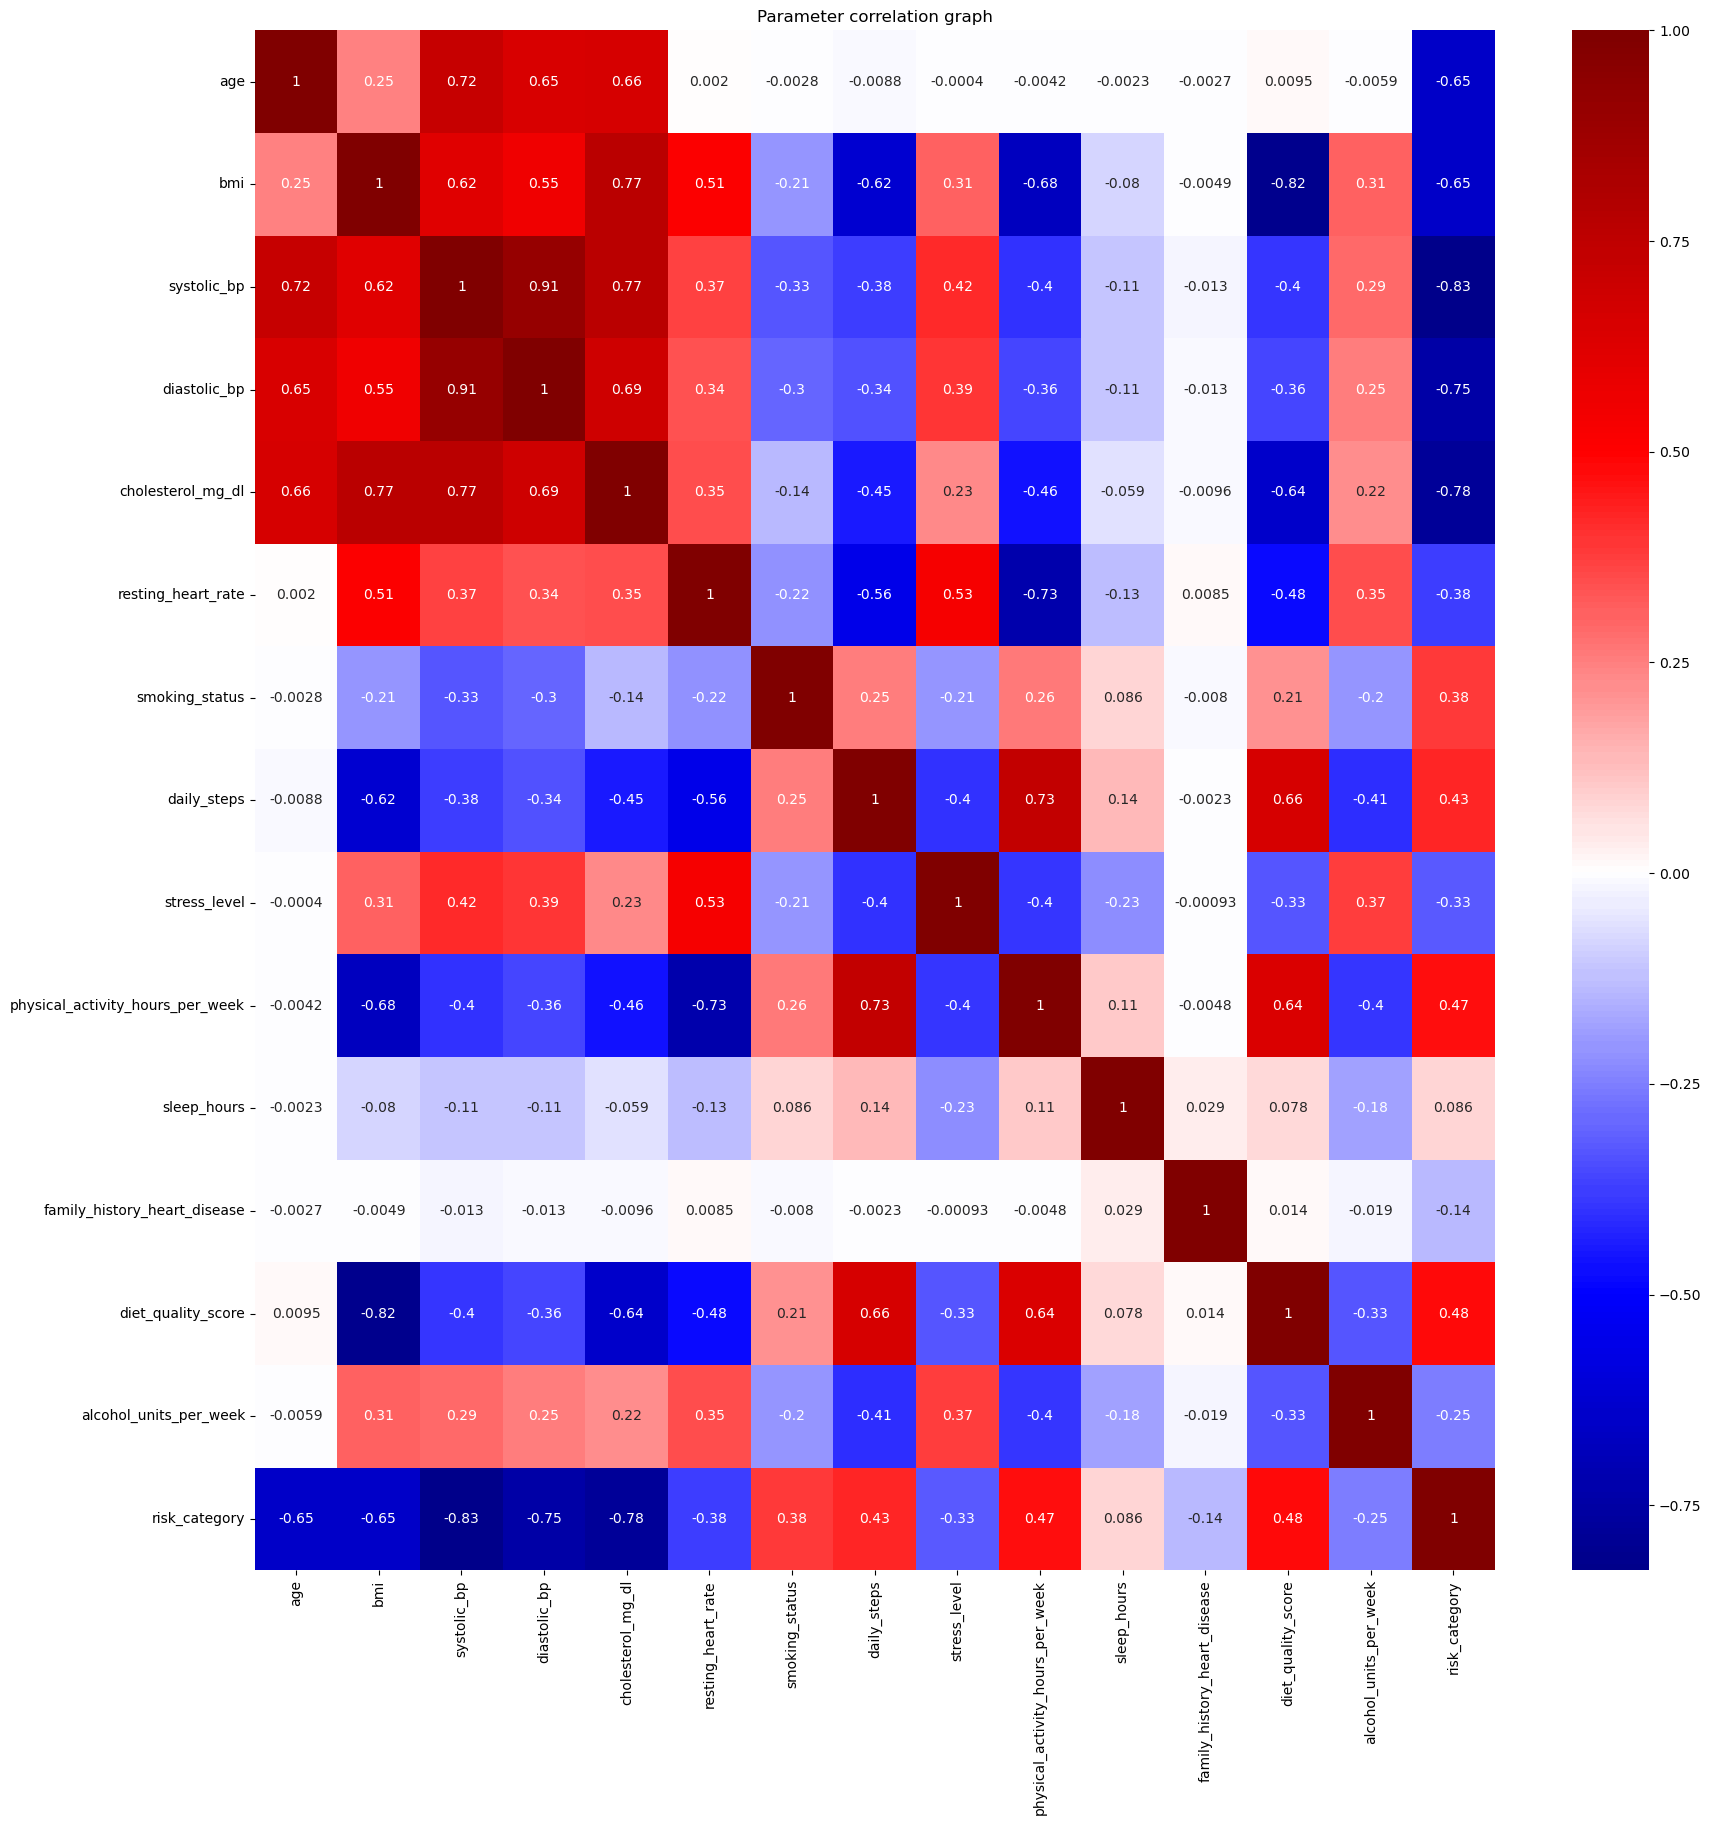

In [4]:
plt.figure(figsize=(20, 20))
seaborn.heatmap(df3.corr(), annot=True, cmap='seismic', center=0)
plt.title('Parameter correlation graph')
plt.show()

In [5]:
# x = df3.drop(['risk_category_High', 'risk_category_Medium', 'risk_category_Low'], axis = 1).to_numpy()
# y = df3[['risk_category_High', 'risk_category_Medium', 'risk_category_Low']].to_numpy()
x = df3.drop(['risk_category'], axis = 1).to_numpy()
y = df3['risk_category'].to_numpy()

In [6]:
from sklearn.model_selection import train_test_split

x_train_f, x_test, y_train_f, y_test = train_test_split(x, y, test_size=0.15, random_state=42)

gran = int(len(x_train_f)*0.1)

x_train = x_train_f[:gran]
y_train = y_train_f[:gran]

x_val = x_train_f[gran:]
y_val = y_train_f[gran:]

In [7]:
import tensorflow as tf
import keras
from tensorflow.keras.callbacks import EarlyStopping

model = keras.Sequential([
    keras.layers.Dense(x_train.shape[1] * 5, input_shape=(x_train.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(x_train.shape[1], activation ='relu', kernel_regularizer='l1'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(3, activation ='softmax')
])


model.compile(  optimizer = keras.optimizers.Adam(learning_rate = 1e-2),
                loss = 'sparse_categorical_crossentropy',
                metrics = ['accuracy']
                )

early_stopping = EarlyStopping(
                    monitor='val_loss',
                    mode='min',
                    patience = 50,
                    min_delta = 0.01,
                    verbose = 0,
                    restore_best_weights = True
                    )

model.fit(
        x = x_train,
        y = y_train,
        batch_size = 16,
        epochs = 2000,
        verbose = 0,
        callbacks = [early_stopping], 
        shuffle = False,
        validation_split = 1,
        validation_data = (x_val, y_val),
        validation_batch_size = 16
        )

train_loss, keras_train_r2 = model.evaluate(x_train, y_train)
test_loss, keras_test_r2 = model.evaluate(x_test, y_test)
print('\nдля нейронной сети R^2 метрика для обучающей \ тестовой выборки:', keras_train_r2, ' \ ', keras_test_r2)

D:\Aninst\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
D:\Aninst\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9036 - loss: 0.4078  
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8958 - loss: 0.4173 

для нейронной сети R^2 метрика для обучающей \ тестовой выборки: 0.9036402702331543  \  0.8957575559616089


In [8]:
class My_Dataset():
    def __init__(self, x, y):
        x_train_f, x_test, y_train_f, y_test = train_test_split(x, y, test_size=0.15, random_state=42)

        gran = int(len(x_train_f)*0.1)

        x_train = x_train_f[:gran]
        y_train = y_train_f[:gran]

        x_val = x_train_f[gran:]
        y_val = y_train_f[gran:]

In [15]:
#from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

class NeuralNetworkTrainer():
    def __init__(self, epochs=500, batch_size=16, verbose=0):
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.model = None

    def fit(self, X, y=None):

        model = keras.Sequential([
            keras.layers.Dense(x_train.shape[1] * 5, input_shape=(x_train.shape[1],)),
            keras.layers.Dropout(0.3),
            keras.layers.Dense(x_train.shape[1], activation ='relu', kernel_regularizer='l1'),
            keras.layers.BatchNormalization(),
            keras.layers.Dense(3, activation ='softmax')
            ])


        model.compile(  optimizer = keras.optimizers.Adam(learning_rate = 1e-2),
                        loss = 'sparse_categorical_crossentropy',
                        metrics = ['accuracy']
                        )

        early_stopping = EarlyStopping(
                            monitor='val_loss',
                            mode='min',
                            patience = 50,
                            min_delta = 0.01,
                            verbose = 0,
                            restore_best_weights = True
                            )

        model.fit(
                x = X,
                y = y,
                batch_size = self.batch_size,
                epochs = self.epochs,
                verbose = self.verbose,
                callbacks = [early_stopping], 
                shuffle = False,
                validation_split = 0.1,
                validation_data = (x_val, y_val),
                validation_batch_size = 16
                )        

        self.model = model
        return self

    def transform(self, X):
        # NeuralNetworkTrainer не изменяет данные, поэтому просто возвращаем X
        return X

    def predict(self, X):
        # Предсказать метки классов для новых данных X
        if self.model is None:
            raise ValueError("Модель не обучена")
        y_pred = self.model.predict(X)
        return np.argmax(y_pred, axis=1)

    def score(self, X, y=None):
        # Оцените производительность модели на данных X и y
        if self.model is None:
            raise ValueError("Модель не обучена")
        y_pred = self.model.predict(X)
        accuracy = accuracy_score(y, np.argmax(y_pred, axis=1))
        return accuracy

# Добавьте NeuralNetworkTrainer в ваш конвейер
pipe = Pipeline([
    ('neural_network_trainer', NeuralNetworkTrainer()),
])

# Запустите конвейер на тренировочных данных
pipe.fit(x_train, y_train)


D:\Aninst\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Pipeline(steps=[('neural_network_trainer',
                 <__main__.NeuralNetworkTrainer object at 0x0000029149BF1FD0>)])

In [66]:
pipe.score(x_train, y_train)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


D:\zmei\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


0.8843683083511777

In [67]:
pipe.score(x_test, y_test)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


D:\zmei\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


0.8824242424242424

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size=8):
        super(NeuralNet, self).__init__()  
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

class PyTorchRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, input_size=14, hidden_size=8, epochs=500, batch_size=32, lr=0.001):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.model = None
        
    def fit(self, X, y):
        X_tensor = torch.FloatTensor(X)
        y_tensor = torch.FloatTensor(y).view(-1, 1)
        
        train_loader = DataLoader(TensorDataset(X_tensor, y_tensor), 
                                 batch_size=self.batch_size, shuffle=True)
        
        self.model = NeuralNet(self.input_size, self.hidden_size)
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        criterion = nn.MSELoss()
    
        for epoch in range(self.epochs):
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                loss = criterion(self.model(batch_X), batch_y)
                loss.backward()
                optimizer.step()
            
            if epoch % 50 == 0:
                print(f'Epoch {epoch}, Loss: {loss.item():.4f}')
        
        return self
    
    def predict(self, x):
        self.model.eval()
        X_tensor = torch.FloatTensor(x)
        with torch.no_grad():
            return self.model(X_tensor).numpy().flatten()
    
    def score(self, x, y):
        return r2_score(y, self.predict(x))

class My_Dataset():
    def __init__(self, x, y):
        x_train_f, x_test, y_train_f, y_test = train_test_split(x, y, test_size=0.15, random_state=42)

        gran = int(len(x_train_f)*0.1)

        self.x_train = x_train_f[:gran]
        self.y_train = y_train_f[:gran]

        self.x_val = x_train_f[gran:]
        self.y_val = y_train_f[gran:]
        
        self.x_test = x_test
        self.y_test = y_test

data = My_Dataset(X, y) 

pipe = Pipeline([
    ('scaler', StandardScaler()), 
    ('regressor', PyTorchRegressor(  
        input_size=data.x_train.shape[1], 
        epochs=500,
        hidden_size=8,
        batch_size=32,
        lr=0.001
    ))
])
print(pipe)
pipe.fit(data.x_train, data.y_train)

y_pred = pipe.predict(data.x_test)

Pipeline(steps=[('scaler', StandardScaler()),
                ('regressor', PyTorchRegressor())])
Epoch 0, Loss: 0.4960
Epoch 50, Loss: 0.1883
Epoch 100, Loss: 0.1581
Epoch 150, Loss: 0.1047
Epoch 200, Loss: 0.1384
Epoch 250, Loss: 0.0808
Epoch 300, Loss: 0.1056
Epoch 350, Loss: 0.0509
Epoch 400, Loss: 0.0551
Epoch 450, Loss: 0.0554


D:\Aninst\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
